(2192, 8)
time                         datetime64[us]
temperature_2m_max                  float64
temperature_2m_min                  float64
precipitation_sum                   float64
relative_humidity_2m_mean             int64
surface_pressure_mean               float64
cloud_cover_mean                      int64
wind_speed_10m_max                  float64
dtype: object
time                         0
temperature_2m_max           0
temperature_2m_min           0
precipitation_sum            0
relative_humidity_2m_mean    0
surface_pressure_mean        0
cloud_cover_mean             0
wind_speed_10m_max           0
dtype: int64
(2192, 8)
(2189, 18)


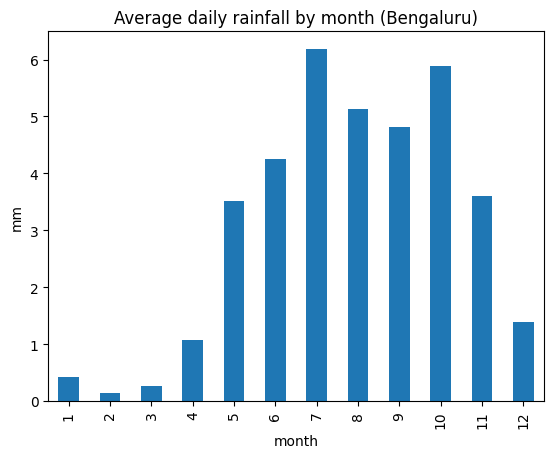

16 features: ['temperature_2m_max', 'temperature_2m_min', 'precipitation_sum', 'relative_humidity_2m_mean', 'surface_pressure_mean', 'cloud_cover_mean', 'wind_speed_10m_max', 'month', 'relative_humidity_2m_mean_lag1', 'relative_humidity_2m_mean_avg3', 'surface_pressure_mean_lag1', 'surface_pressure_mean_avg3', 'cloud_cover_mean_lag1', 'cloud_cover_mean_avg3', 'precipitation_sum_lag1', 'precipitation_sum_avg3']
(1532, 16) (328, 16) (329, 16)
Logistic Regression
[[144  46]
 [ 32 106]]
Decision Tree
[[139  51]
 [ 39  99]]
Random Forest
[[154  36]
 [ 43  95]]
XGBoost
[[135  55]
 [ 34 104]]
              precision    recall  f1-score   support

           0       0.92      0.70      0.79       181
           1       0.71      0.93      0.81       148

    accuracy                           0.80       329
   macro avg       0.82      0.81      0.80       329
weighted avg       0.83      0.80      0.80       329

ROC-AUC: 0.9036882186053457


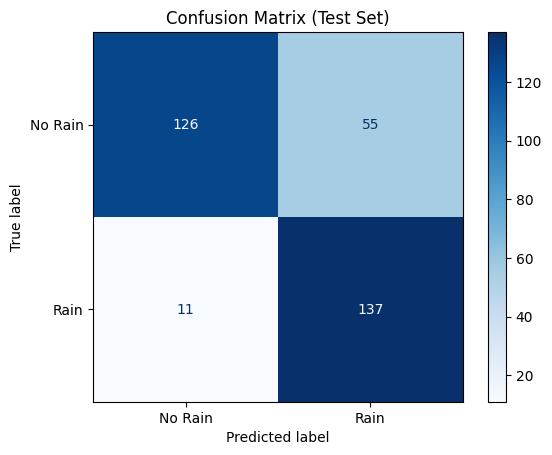

['.ipynb_checkpoints', 'app.py', 'features.pkl', 'rain-fall-prediction', 'rain_model.pkl', 'run_app.bat']
Date: 2026-10-01
Chance of rain tomorrow: 53%
Prediction: Rain


In [1]:
# %% [markdown]
# # Rainfall Prediction (Bengaluru)
# Predict whether it will rain **tomorrow** using real weather data from Open-Meteo.
# 
# **Target:** `RainTomorrow` (1 = rain of 1 mm or more tomorrow, 0 = no rain)
# 
# **Steps:** download data, clean, create features, split by date, compare models, final test, save model, live prediction.

# %% [markdown]
# ## 1. Imports

# %%
import os
import joblib
import requests
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)

# Folder where the model files will be saved
PROJECT = r"C:\Users\SUMAN\Rainfall_project"
os.makedirs(PROJECT, exist_ok=True)

# %% [markdown]
# ## 2. Download real historical data (Open-Meteo)

# %%
COLS = ["temperature_2m_max", "temperature_2m_min", "precipitation_sum",
        "relative_humidity_2m_mean", "surface_pressure_mean",
        "cloud_cover_mean", "wind_speed_10m_max"]

url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": 12.97, "longitude": 77.59,          # Bengaluru
    "start_date": "2019-01-01", "end_date": "2024-12-31",
    "daily": COLS, "timezone": "Asia/Kolkata",
}
data = requests.get(url, params=params).json()
df = pd.DataFrame(data["daily"])
print(df.shape)
df.head()

# %% [markdown]
# ## 3. Clean the data

# %%
df = df.drop_duplicates()
df["time"] = pd.to_datetime(df["time"])
df = df.sort_values("time").reset_index(drop=True)

print(df.dtypes)
print(df.isna().sum())
df.describe()

# %%
# Fill small gaps using neighbouring days
df[COLS] = df[COLS].interpolate()
df = df.dropna(subset=COLS)
print(df.shape)

# %% [markdown]
# ## 4. Create the target and features
# **Target:** `RainTomorrow` = 1 if tomorrow's rainfall is 1 mm or more.

# %%
# Target: shift rainfall up by one day so each row describes today and its label describes tomorrow
df["RainTomorrow"] = (df["precipitation_sum"].shift(-1) >= 1).astype(int)
df = df.iloc[:-1]            # last day has no tomorrow

# Season feature
df["month"] = df["time"].dt.month

# Lag features: yesterday's value and 3-day average
for col in ["relative_humidity_2m_mean", "surface_pressure_mean", "cloud_cover_mean", "precipitation_sum"]:
    df[col + "_lag1"] = df[col].shift(1)
    df[col + "_avg3"] = df[col].rolling(3).mean()

df = df.dropna().reset_index(drop=True)
print(df.shape)
df["RainTomorrow"].value_counts(normalize=True)

# %% [markdown]
# ## 5. Quick exploration

# %%
df.groupby("month")["precipitation_sum"].mean().plot(kind="bar")
plt.title("Average daily rainfall by month (Bengaluru)")
plt.ylabel("mm")
plt.show()

df.groupby("RainTomorrow")[["relative_humidity_2m_mean", "cloud_cover_mean", "surface_pressure_mean"]].mean()

# %% [markdown]
# ## 6. Train / validation / test split (by date)

# %%
features = [c for c in df.columns if c not in ["time", "RainTomorrow"]]
print(len(features), "features:", features)

X, y = df[features], df["RainTomorrow"]
n = len(df)
i1, i2 = int(n * 0.70), int(n * 0.85)

X_train, y_train = X.iloc[:i1],   y.iloc[:i1]
X_val,   y_val   = X.iloc[i1:i2], y.iloc[i1:i2]
X_test,  y_test  = X.iloc[i2:],   y.iloc[i2:]
print(X_train.shape, X_val.shape, X_test.shape)

# %% [markdown]
# ## 7. Helper to evaluate models on the validation set

# %%
results = []

def evaluate(name, model):
    pred = model.predict(X_val)
    prob = model.predict_proba(X_val)[:, 1]
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_val, pred),
        "Precision": precision_score(y_val, pred),
        "Recall": recall_score(y_val, pred),
        "F1": f1_score(y_val, pred),
        "ROC-AUC": roc_auc_score(y_val, prob),
    })
    print(name)
    print(confusion_matrix(y_val, pred))

# %% [markdown]
# ## 8. Logistic Regression

# %%
log_model = make_pipeline(StandardScaler(),
                          LogisticRegression(class_weight="balanced", max_iter=1000))
log_model.fit(X_train, y_train)
evaluate("Logistic Regression", log_model)

# %% [markdown]
# ## 9. Decision Tree

# %%
dt_model = DecisionTreeClassifier(max_depth=6, class_weight="balanced", random_state=42)
dt_model.fit(X_train, y_train)
evaluate("Decision Tree", dt_model)

# %% [markdown]
# ## 10. Random Forest

# %%
rf_model = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42)
rf_model.fit(X_train, y_train)
evaluate("Random Forest", rf_model)

# %% [markdown]
# ## 11. XGBoost

# %%
ratio = (y_train == 0).sum() / (y_train == 1).sum()
xgb_model = XGBClassifier(n_estimators=200, scale_pos_weight=ratio,
                          eval_metric="logloss", random_state=42)
xgb_model.fit(X_train, y_train)
evaluate("XGBoost", xgb_model)

# %% [markdown]
# ## 12. Compare all models (validation set)

# %%
comparison = pd.DataFrame(results).round(3).sort_values("F1", ascending=False)
comparison

# %% [markdown]
# ## 13. Final test with the best model (run only once)

# %%
best_model = log_model   # change this if another model wins in your table above
test_pred = best_model.predict(X_test)
print(classification_report(y_test, test_pred))
print("ROC-AUC:", roc_auc_score(y_test, best_model.predict_proba(X_test)[:, 1]))

# %%
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test,
                                      display_labels=["No Rain", "Rain"], cmap="Blues")
plt.title("Confusion Matrix (Test Set)")
plt.show()

# %% [markdown]
# ## 14. Save the model for the Streamlit app

# %%
joblib.dump(best_model, os.path.join(PROJECT, "rain_model.pkl"))
joblib.dump(features, os.path.join(PROJECT, "features.pkl"))
print(os.listdir(PROJECT))

# %% [markdown]
# ## 15. Live prediction for tomorrow

# %%
params = {
    "latitude": 12.97, "longitude": 77.59, "daily": COLS,
    "past_days": 5, "forecast_days": 1, "timezone": "Asia/Kolkata",
}
live = requests.get("https://api.open-meteo.com/v1/forecast", params=params).json()

d = pd.DataFrame(live["daily"])
d["time"] = pd.to_datetime(d["time"])
d["month"] = d["time"].dt.month
for col in ["relative_humidity_2m_mean", "surface_pressure_mean", "cloud_cover_mean", "precipitation_sum"]:
    d[col + "_lag1"] = d[col].shift(1)
    d[col + "_avg3"] = d[col].rolling(3).mean()

today = d.iloc[[-1]]
prob = best_model.predict_proba(today[features])[0][1]
print("Date:", today["time"].dt.date.values[0])
print(f"Chance of rain tomorrow: {prob:.0%}")
print("Prediction:", "Rain" if prob >= 0.5 else "No rain")